# Laborator 11 -> LRF

Se cere identificarea comunităților existente într-o rețea folosind:
- un algoritm predefinit intr-o biblioteca specializata (e.g. networkx, gephi, altele);
- un algoritm evolutiv.

Cum este creat setul de date?

LFR_benchmark_graph(n,tau1,tau2,mu)

- n: nr de noduri
- tau1: exponent pt conexiuni -> controleaza inegalitatea popularitatii
- tau2: exponent pt comunitati -> controleaza inegalitatea dimensiunii comunitatilor
- mu: mixing -> proportia de conexiuni pe care un nod le are cu exteriorul
- averange_degree -> gradul mediu al unui nod
- se mai pot adauga parametrii precum: max_degree, min_community, max_community si seed

Controlul inegalitatii:
Acei exponenti "tau" care am precizat ca se ocupa cu controlul inegalitatii spun cat de abrupta este panta intre majoritatea componentelor ("de rand") si minoritati (acele "superstar-uri"). Cu cat valoarea acestor exponenti este mai mica, cu atat diferenta este mai mare. Cu cat valoarea este mai mare, cu atat datele sunt mai echilibrate.

In [14]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import networkx as nx
from networkx.linalg.graphmatrix import adjacency_matrix
from pyvis.network import Network

### Vizualizarea retelei

In acest pas, scopul este sa vizualizam modul in care este organizata reteaua si sa ne facem o idee cu privire la care ar putea sa fie posibilele comunitati. Spre deosebire de retelele anterioare, aici nu vom avea un ground truth.

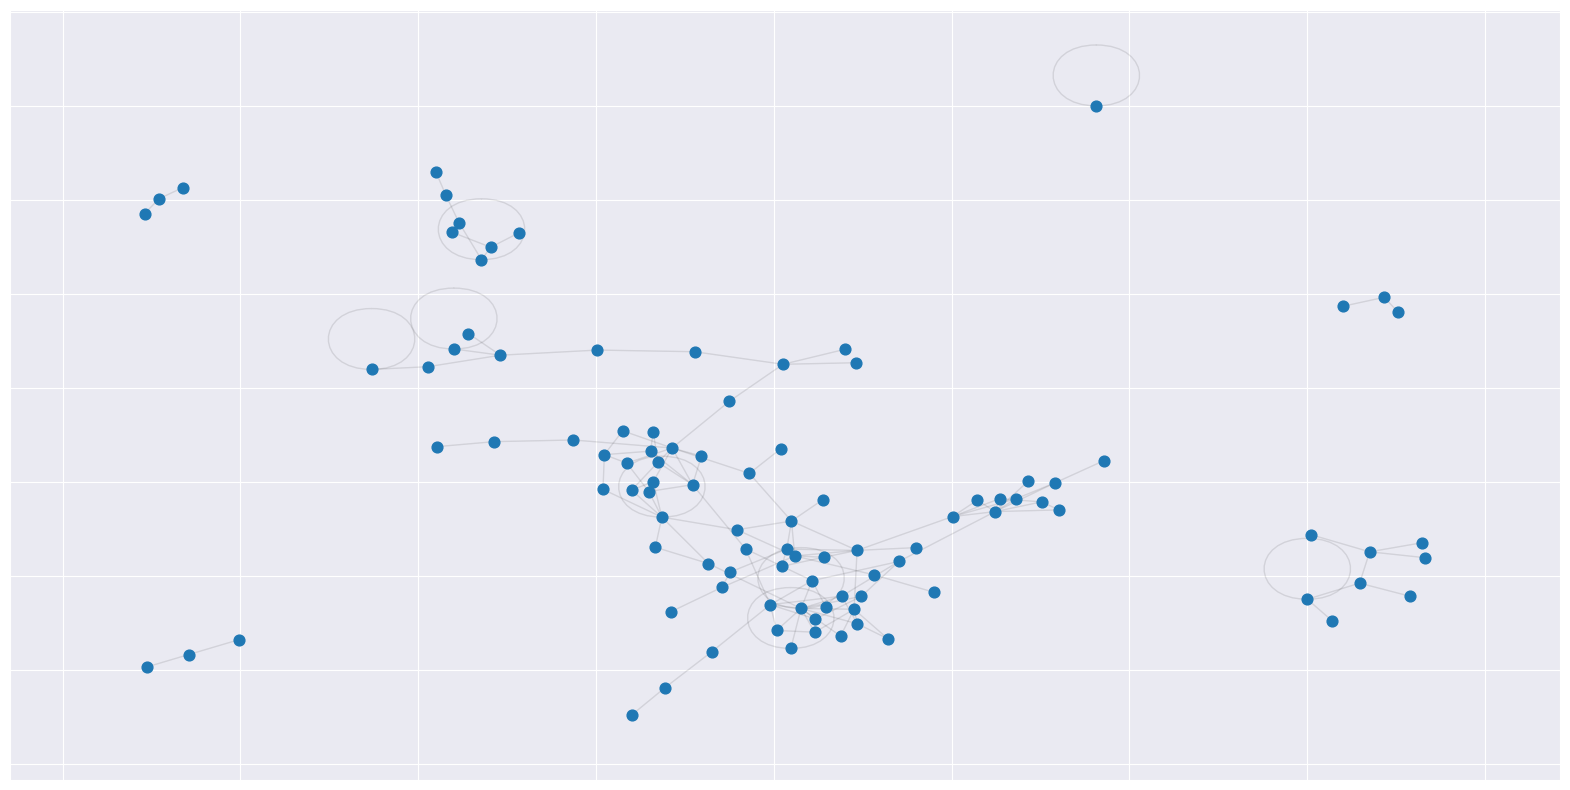

In [15]:
# graful care descrie reteaua
nrOfNodes = 100
popularityExponent = 2.3
communityExponent = 2.1
mixing = 0.1
averageDegree = 3

G = nx.LFR_benchmark_graph(n = nrOfNodes, tau1 = popularityExponent, tau2 = communityExponent, mu = mixing,average_degree = averageDegree,seed = 11,min_community = 10, max_community = 50, max_degree = 50)

pos = nx.spring_layout(G,seed = 11)

plt.figure(figsize=(20, 10))
nx.draw_networkx_nodes(G, pos, node_size=60)
nx.draw_networkx_edges(G, pos, alpha=0.1)
plt.show(G)

### Determinarea comunitatilor cu tool

In acest pas, se foloseste algoritmul louvai din libraria networkx -> determina care sunt comunitatile.
Ulterior, se reda grafic rezultatul obtinut.

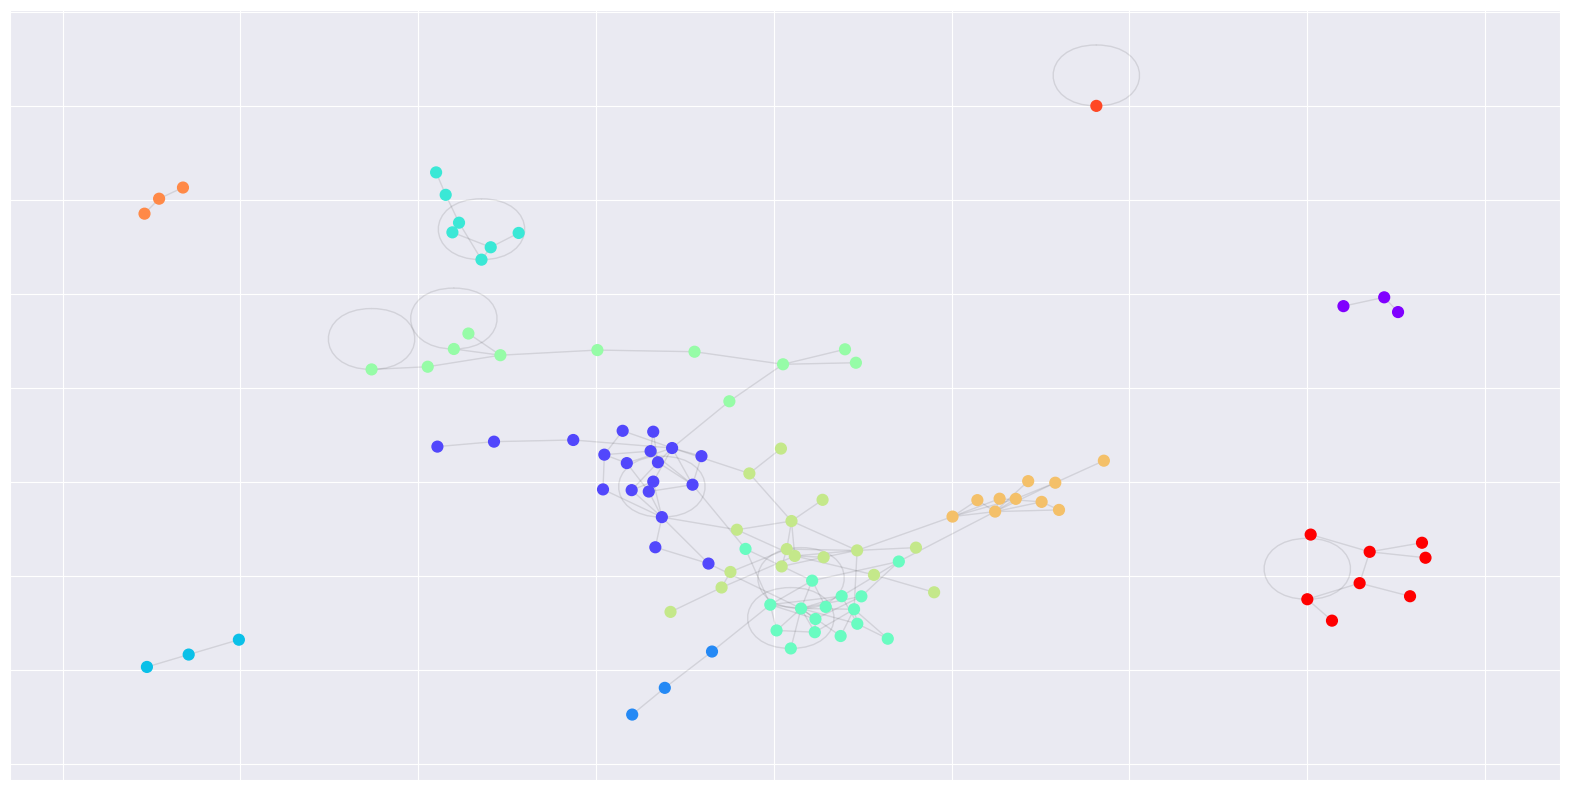

In [16]:
from networkx.algorithms import community

labelList = list(G.nodes())

# se introduce si param seed, deoarece, in cadrul algoritmului exista acea comp. aleatorie
# se vor returna seturi (comunitatile) ce contin id-urile
communityTOOL = community.louvain_communities(G, seed=11)

# reprezentarea numerica -> utila pentru evaluarea performantei
nameToId = {name: idx for idx, name in enumerate(G.nodes())}
communityTOOLNumerical = []

for nodeSet in communityTOOL:
    # se transforma fiecare nume in id-ul sau
    currentCommunity = [nameToId[nodeName] for nodeName in nodeSet]
    communityTOOLNumerical.append(currentCommunity)

communities = [0] * len(labelList)
for idComunity, com in enumerate(communityTOOLNumerical):
    for nod in com:
        #G.nodes[nod]['group'] = idComunity
        communities[nod] = idComunity


pos = nx.spring_layout(G,seed = 11)
plt.figure(figsize=(20, 10))

nx.draw_networkx_nodes(G, pos, node_size=60, cmap=plt.cm.rainbow,node_color = communities)
nx.draw_networkx_edges(G, pos, alpha=0.1)
plt.show(G)

### Evaluarea performantei -> scorul de modularitate

Acest tip de evaluare a performantei algoritmului se bazeaza pe functia de fitness. Astfel, scorul de modularitate obtinut este calculat dupa urmatoarea formula: SUM(eii - ai ^2), unde:
- eii -> nr de muchii care sunt cuprinse complet in comunitatea curenta
- ai -> nr de muchii ce au minim o extremitate cuprinsa in comunitatea curenta

Interpretarea scorului:
- <= 0: algoritmul ghiceste, genereaza random comunitatile
- 0.2 - 0.6: sweet spot -> majoritatea algoritmilor o sa aiba un scor cuprins intre aceste 2 valori
- 1: impartire perfecta

In [17]:
def modularity(communities, adjacencyMatrix):
    m = sum(sum(row) for row in adjacencyMatrix) / 2
    Q = 0
    for community in communities:
        for i in community:
            for j in community:
                ki = sum(adjacencyMatrix[i])
                kj = sum(adjacencyMatrix[j])

                Q += adjacencyMatrix[i][j] - ki * kj / (2 * m)

    Q *= 1/(2*m)
    return Q

# se obtine matricea de adiacenta
adjacencyMatrix = nx.to_numpy_array(G).tolist()
print(modularity(communityTOOLNumerical, adjacencyMatrix))

0.7731250943111437


### Determinarea comunitatilor folosind cod propriu

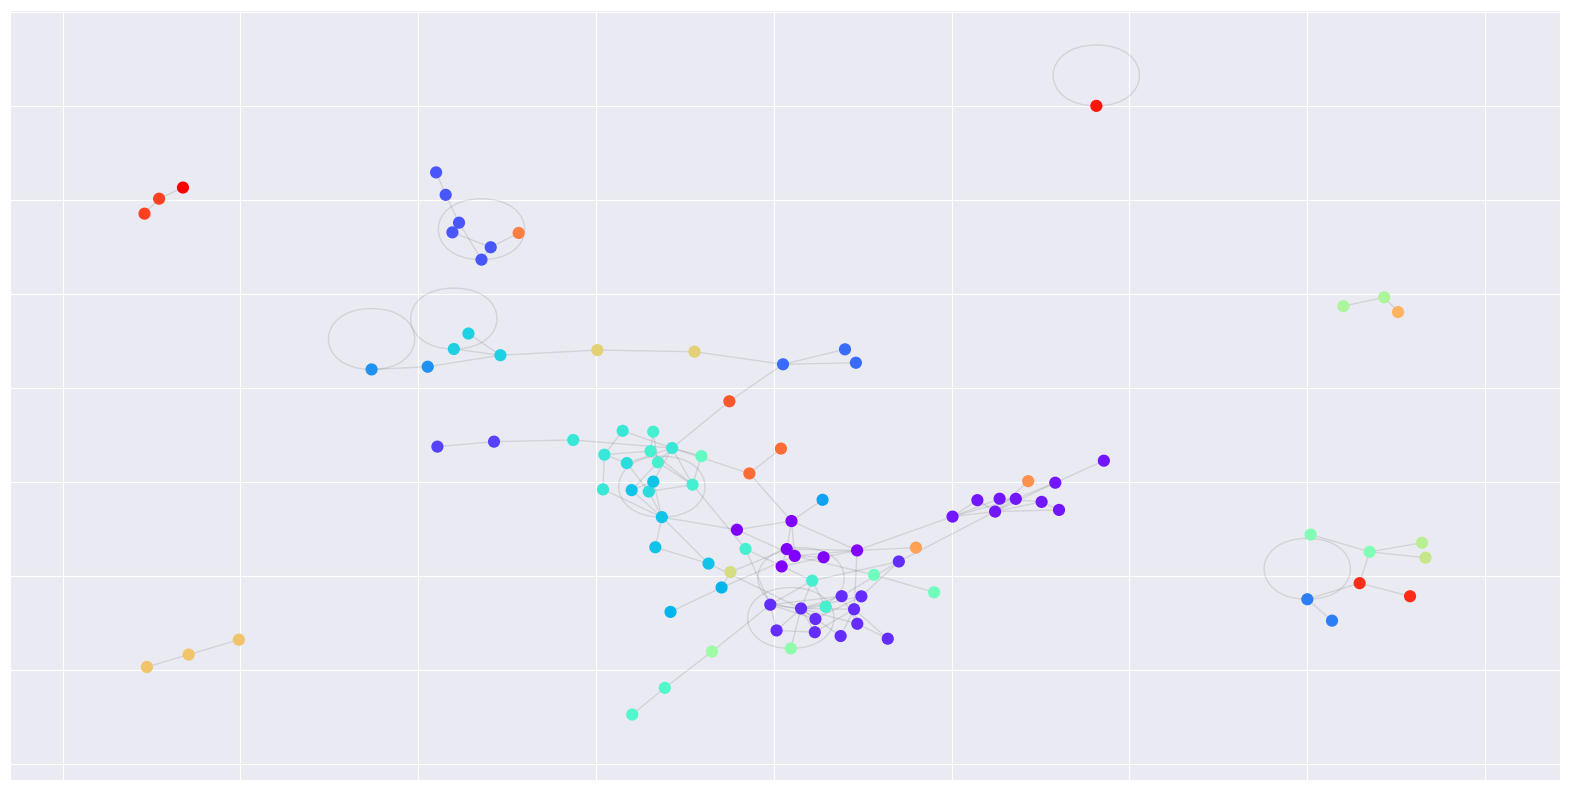

In [18]:
from fitnessModularity import fitnessFunction
import functools
from GeneticAlgorithm import GA

fitnessFunc = functools.partial(fitnessFunction, adjacencyMatrix=adjacencyMatrix)

problParam = {
    'adjacencyMatrix': adjacencyMatrix,
    'function': fitnessFunc
}

param = {
    'popSize': len(G.nodes()),
    'noGen': 500,
    'mutProb': 0.1
}

ga = GA(param=param, problParam=problParam)
best = ga.run()
decodedBest = best.decode()

communities = [0] * len(labelList)

# se seteaza noile comunitati determinate in graf
for communityId, nodesInCommunity in enumerate(decodedBest):
    for nodeIndex in nodesInCommunity:
        #nodeName = nodesList[nodeIndex]
        #G.nodes[nodeName]['group'] = communityId

        communities[nodeIndex] = communityId


pos = nx.spring_layout(G,seed = 11)
plt.figure(figsize=(20, 10))

nx.draw_networkx_nodes(G, pos, node_size=60, cmap=plt.cm.rainbow,node_color = communities)
nx.draw_networkx_edges(G, pos, alpha=0.1)
plt.show(G)

### Evaluarea performantei -> scorul de modularitate

In [19]:
print(modularity(decodedBest, adjacencyMatrix))

0.5855842261455638
